# AllLife Bank

## Business Context
AllLife Bank is a mid-sized, fast-growing financial institution that offers a range of retail banking services, including savings and checking accounts, fixed deposits, and personal loans. The bank’s business model is centered on building long-term customer relationships, expanding its retail footprint, and growing its loan portfolio to drive sustainable profitability through interest income. It currently relies on a large base of liability customers (depositors) but faces a significant under-representation of asset customers (borrowers). To drive profitability through interest income, the bank must aggressively expand its loan portfolio by converting existing depositors into personal loan customers. The bank aims to optimize its personal loan marketing strategy. Rather than targeting customers based only on static attributes, the bank wants to first understand customer spending behavior and then use that behavioral insight to predict loan acceptance likelihood

### Objective
To clean, explore and visualise the dataset to:
- Predict a customers expected monthly credit card spending.
- Use that prediction with other variables to identify customers who are most likely to accept a loan offer.

### Dataset given

I have been provided with the Loan_Modelling dataset. The columns and defintions are as follows:
* `ID`: Customer ID 

* `Age`: Customer’s age in completed years 

* `Experience`: #years of professional experience 

* `Income`: Annual income of the customer (in thousand dollars) 

* `ZIP Code`: Home Address ZIP code. 

* `Family`: the Family size of the customer 

* `CCAvg`: Average spending on credit cards per month (in thousand dollars) 

* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional 

* `Mortgage`: Value of house mortgage if any. (in thousand dollars) 

* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes) 

* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes) 

* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes) 

* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes) 

* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes) 

### Importing libraries

In [1]:
# Libraries that help with data maniuplation
import numpy as np
import pandas as pd

# Libraries that help with data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score,mean_absolute_percentage_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

sns.set(style = 'whitegrid')

In [2]:
# Load the dataset
data = pd.read_csv('Loan_Modelling.csv')

In [3]:
# Create a new copy of the data so we don't lose the original.
df = data.copy()

In [4]:
# View the first 10 rows to get an idea of the data.
df.head(10)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
5,6,37,13,29,92121,4,0.4,2,155,0,0,0,1,0
6,7,53,27,72,91711,2,1.5,2,0,0,0,0,1,0
7,8,50,24,22,93943,1,0.3,3,0,0,0,0,0,1
8,9,35,10,81,90089,3,0.6,2,104,0,0,0,1,0
9,10,34,9,180,93023,1,8.9,3,0,1,0,0,0,0


Looking at the columns and definitions, the column ID is just a column that will uniquely identify the customer in the dataset and will not help us to predict if the customers average spending on a credit card or if they will accept a loan. For that reason I will drop this from our dataset.

In [5]:
# Remove ID from our dataset.
df.drop(columns = 'ID',inplace = True)

## Dataset Overview
- How many rows/columns in our dataset?

In [6]:
# Number of rows and columns in our dataset.
df.shape

(5000, 13)

In [7]:
# Column names
df.columns

Index(['Age', 'Experience', 'Income', 'ZIPCode', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard'],
      dtype='str')

We already know these are the columns and the definitions of these columns are shown above.

In [8]:
#Check the datatypes and the number of non-nulls in our dataset.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIPCode             5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal_Loan       5000 non-null   int64  
 9   Securities_Account  5000 non-null   int64  
 10  CD_Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 507.9 KB


In [9]:
# Check for duplicates.
df.duplicated().sum()

np.int64(0)

There are no duplicates in the dataset so do not need to worry about removing them.

We see that all the variables are represented numerically, even though some are discrete categorical and others are continous.
Numerical Continous features are:
- Age
- Experience
- Income
- CCAvg(Target variable for model 1)
- Mortgage

Numerical Discrete features are:
- ZipCode
- Family
- Education
- Personal_Loan(Target variable for model 2)
- Securities_Account
- CD_Account
- Online
- CreditCard

Out of these variables for the first problem, we want to understand Customer Spending Behaviour. The target variable is CCAvg.Since CCAvg is continous, we are solving a regression problem.


We see that there are no null values in our dataset. When looking through our data-types and comparing it to the defintion above, we see that these data-types all make sense given the context. Now that we are happy with the data-types and there are no nulls, we can next look at the summary statistics to see if there are any annomalies in our data.

In [10]:
# Check number of unique values for ZIPCode since it's categorical.
df['ZIPCode'].nunique()

467

In [11]:
df.drop(columns= 'ZIPCode',inplace = True)

There are a lot of values for this field. If we were to one hot encode this in our model this would cause problems since we would have 466 extra features for this one field and that would overcomplicate the problem and for each row there would be 466 columns of 0 and one row with 1 which would make it difficult for the Machine Learning model to identify patterns. I am not sure how to represent this in my code so I will drop this from my model.

In [12]:
# Look at the summary statistics of our numerical columns.
df.describe()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,45.338400,20.104600,73.774200,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,11.463166,11.467954,46.033729,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,23.000000,-3.000000,8.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,35.000000,10.000000,39.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,45.000000,20.000000,64.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,55.000000,30.000000,98.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,67.000000,43.000000,224.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


After looking at this, we see the following potential flags in the data.
- Experience should be greater or equal to 0 but we have a value of -3. We will need to investigate this.
- The minimum for CCAvg is 0. This indicates that some customers do not spend anything on their credit cards. This is not nesccarily incorrect but it is something worth noting.


In [13]:
# Investigate rows with Experience less than 0.
df[df['Experience'] < 0]

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
89,25,-1,113,4,2.30,3,0,0,0,0,0,1
226,24,-1,39,2,1.70,2,0,0,0,0,0,0
315,24,-2,51,3,0.30,3,0,0,0,0,1,0
451,28,-2,48,2,1.75,3,89,0,0,0,1,0
524,24,-1,75,4,0.20,1,0,0,0,0,1,0
536,25,-1,43,3,2.40,2,176,0,0,0,1,0
540,25,-1,109,4,2.30,3,314,0,0,0,1,0
576,25,-1,48,3,0.30,3,0,0,0,0,0,1
583,24,-1,38,2,1.70,2,0,0,0,0,1,0
597,24,-2,125,2,7.20,1,0,0,1,0,0,1


We have 52 rows out of 500(about 1% of data) with neagtive experience The negative values are between -1 and -3. I have a hypothesis that these might be typos in data-entry and the negative values should be positive. When looking at these rows, we can see that the ages of these customers are between 23-29 Most people who are at this age have a small amount of experience so 1-3 years of experience for this age range is realistic. Also if we look at their income, we see that there are values that are above 100,000 thousand dollars. To have an income that high for no years of experience would be highly unlikely so that is why I have chosen to convert these negative experience into the absolute values. We will do this after spliting to train and test.

## Univariate Analysis

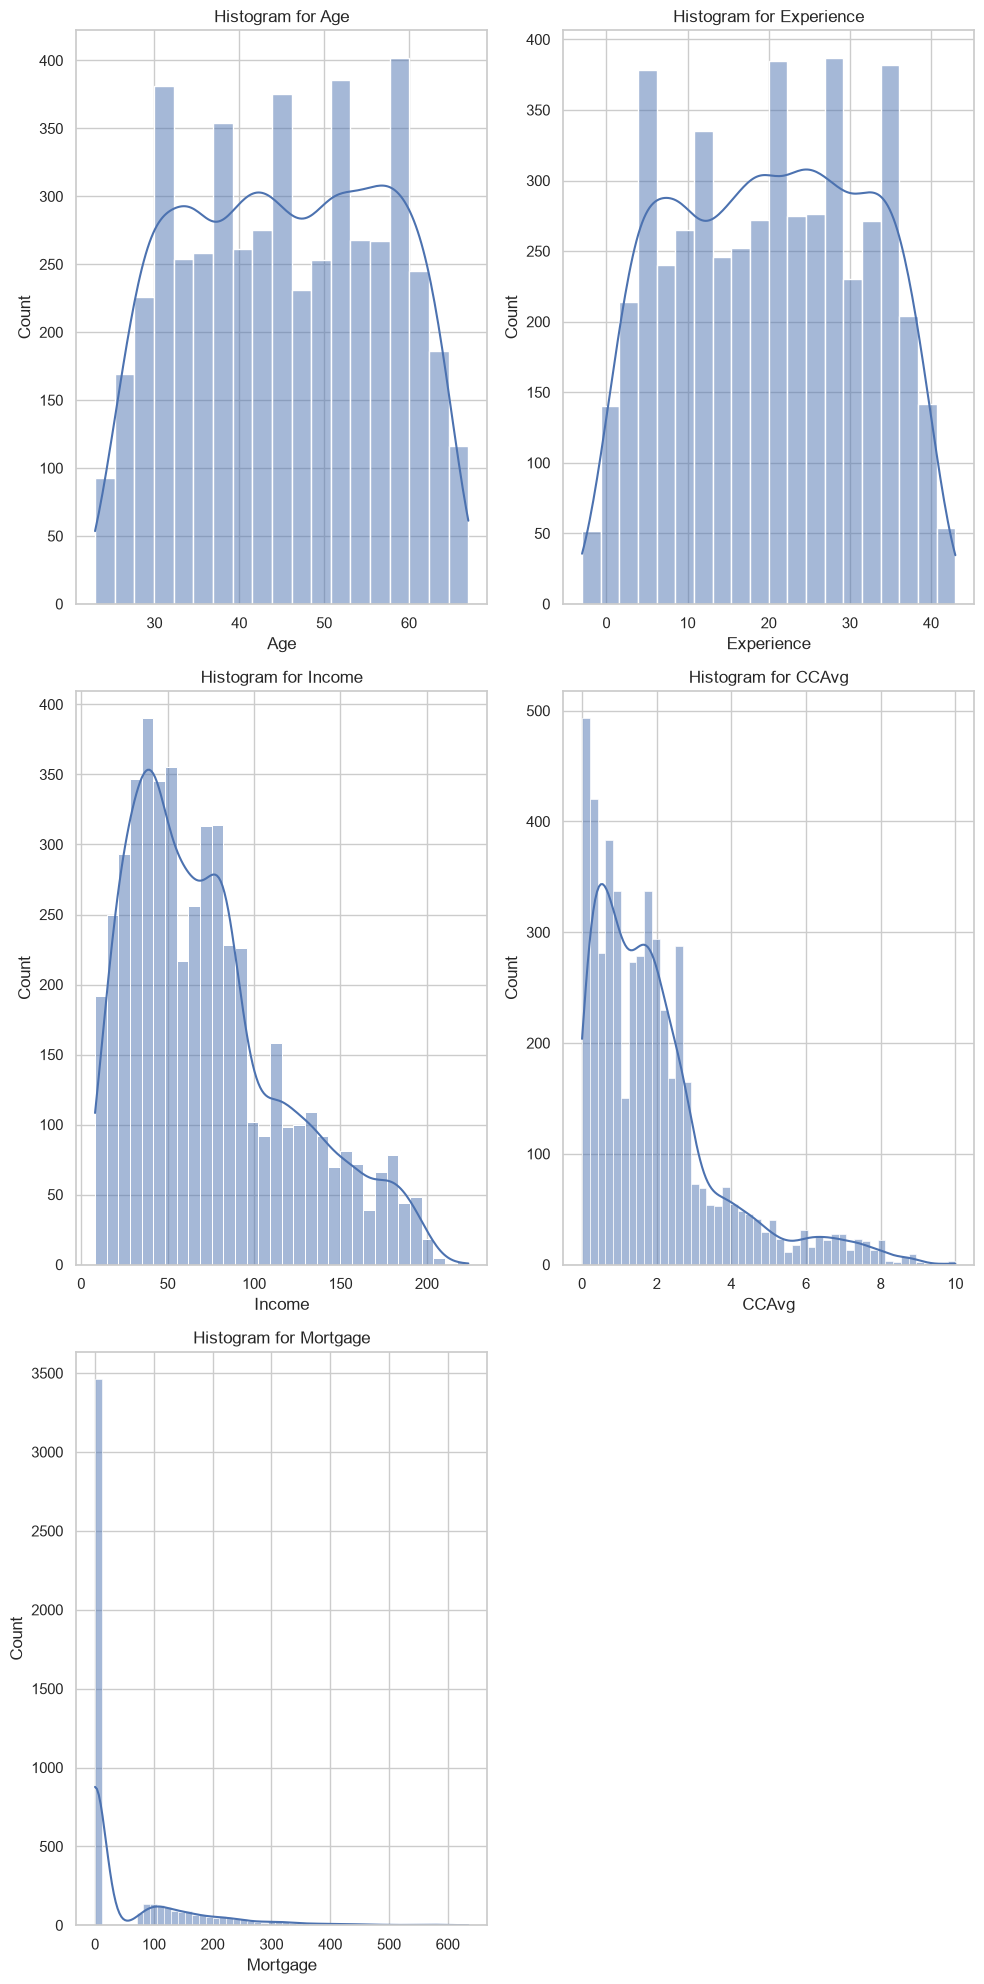

In [14]:
continous_columns = ['Age','Experience','Income','CCAvg','Mortgage']
fig,axes = plt.subplots(nrows = 3, ncols = 2, figsize = (10,20))
axes_flat = axes.flatten()
for i, col_name in enumerate(continous_columns):
    sns.histplot(x = df[col_name], kde = True, ax = axes_flat[i])
    axes_flat[i].set_title(f'Histogram for {col_name}')
axes_flat[5].set_visible(False)
plt.tight_layout()
plt.show()

From these plots:
- Age and Experience are not skewed(although not bell shaped). They are both similary distributed.
- Income is positively skewed to the right with majority of people with smaller incomes and then we have a few people on the upper end income.
- CCAvg is also positively skewed to the right and similar to income. One important note is that there is a high proportion of customers who have 0 as CCAvg. This may indicate they don't have a credit card.
- Mortgage is also heavily skewed to the right. Majority of the customers in our dataset do not have a mortgage. This couuld be because they are too young and have no bought a house or maybe they have finsihed of paying a mortgage.

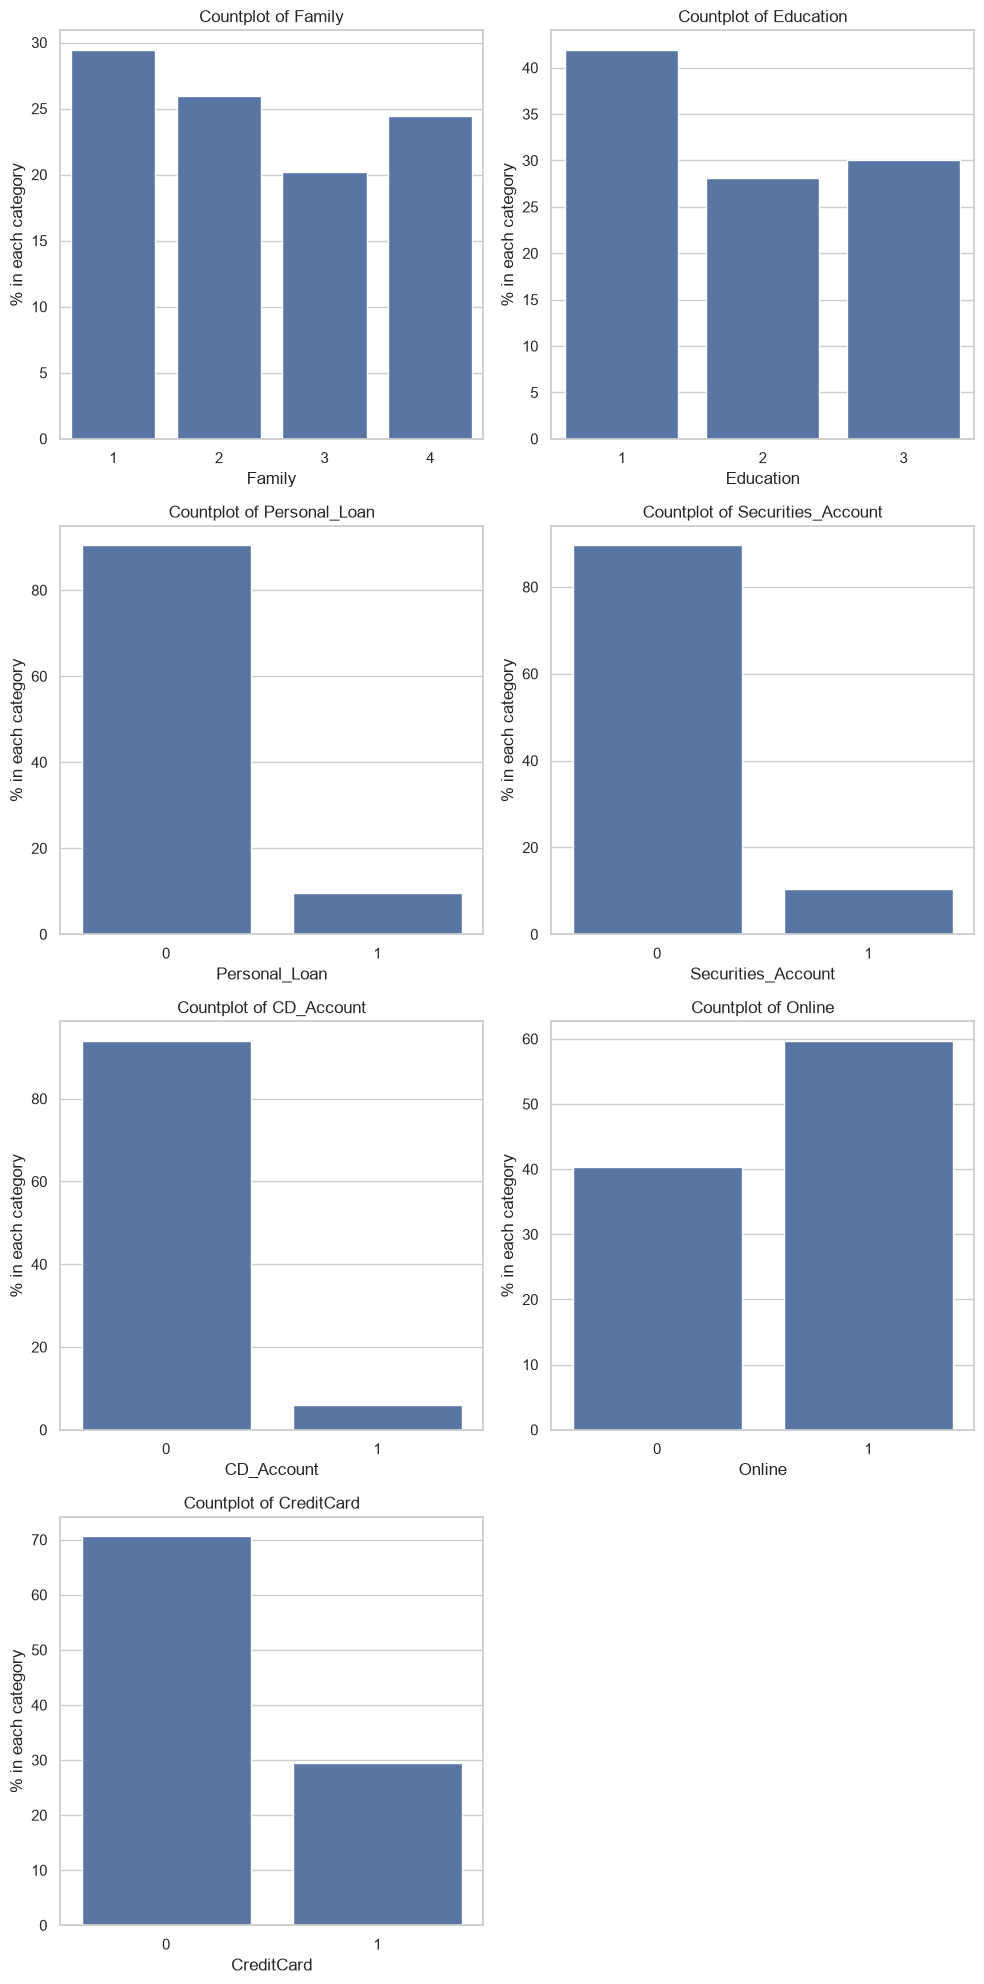

In [15]:
categorical_columns = ['Family','Education','Personal_Loan','Securities_Account','CD_Account','Online','CreditCard']
fig, axes = plt.subplots(nrows = 4, ncols = 2, figsize = (10,20))
axes_flatten = axes.flatten()
for i,col_name in enumerate(categorical_columns):
    percentage_split_categorical_fields =  (df[col_name].value_counts(normalize = True) * 100).reset_index()
    percentage_split_categorical_fields.columns = [col_name, 'Percentage']
    sns.barplot(x = col_name,y = 'Percentage',data = percentage_split_categorical_fields,ax = axes_flatten[i])
    axes_flatten[i].set_title(f'Countplot of {col_name}')
    axes_flatten[i].set_ylabel('% in each category')
axes_flatten[7].set_visible(False)
plt.tight_layout()
plt.show()


From these plots:
- Family, Education, OnlineAccount are quite balanced.
- Credit Card is slightly unbalanced.
- CD_Account, Securities_Account and PersonalLoan are heavily unbalanced

## Bivariate Analysis

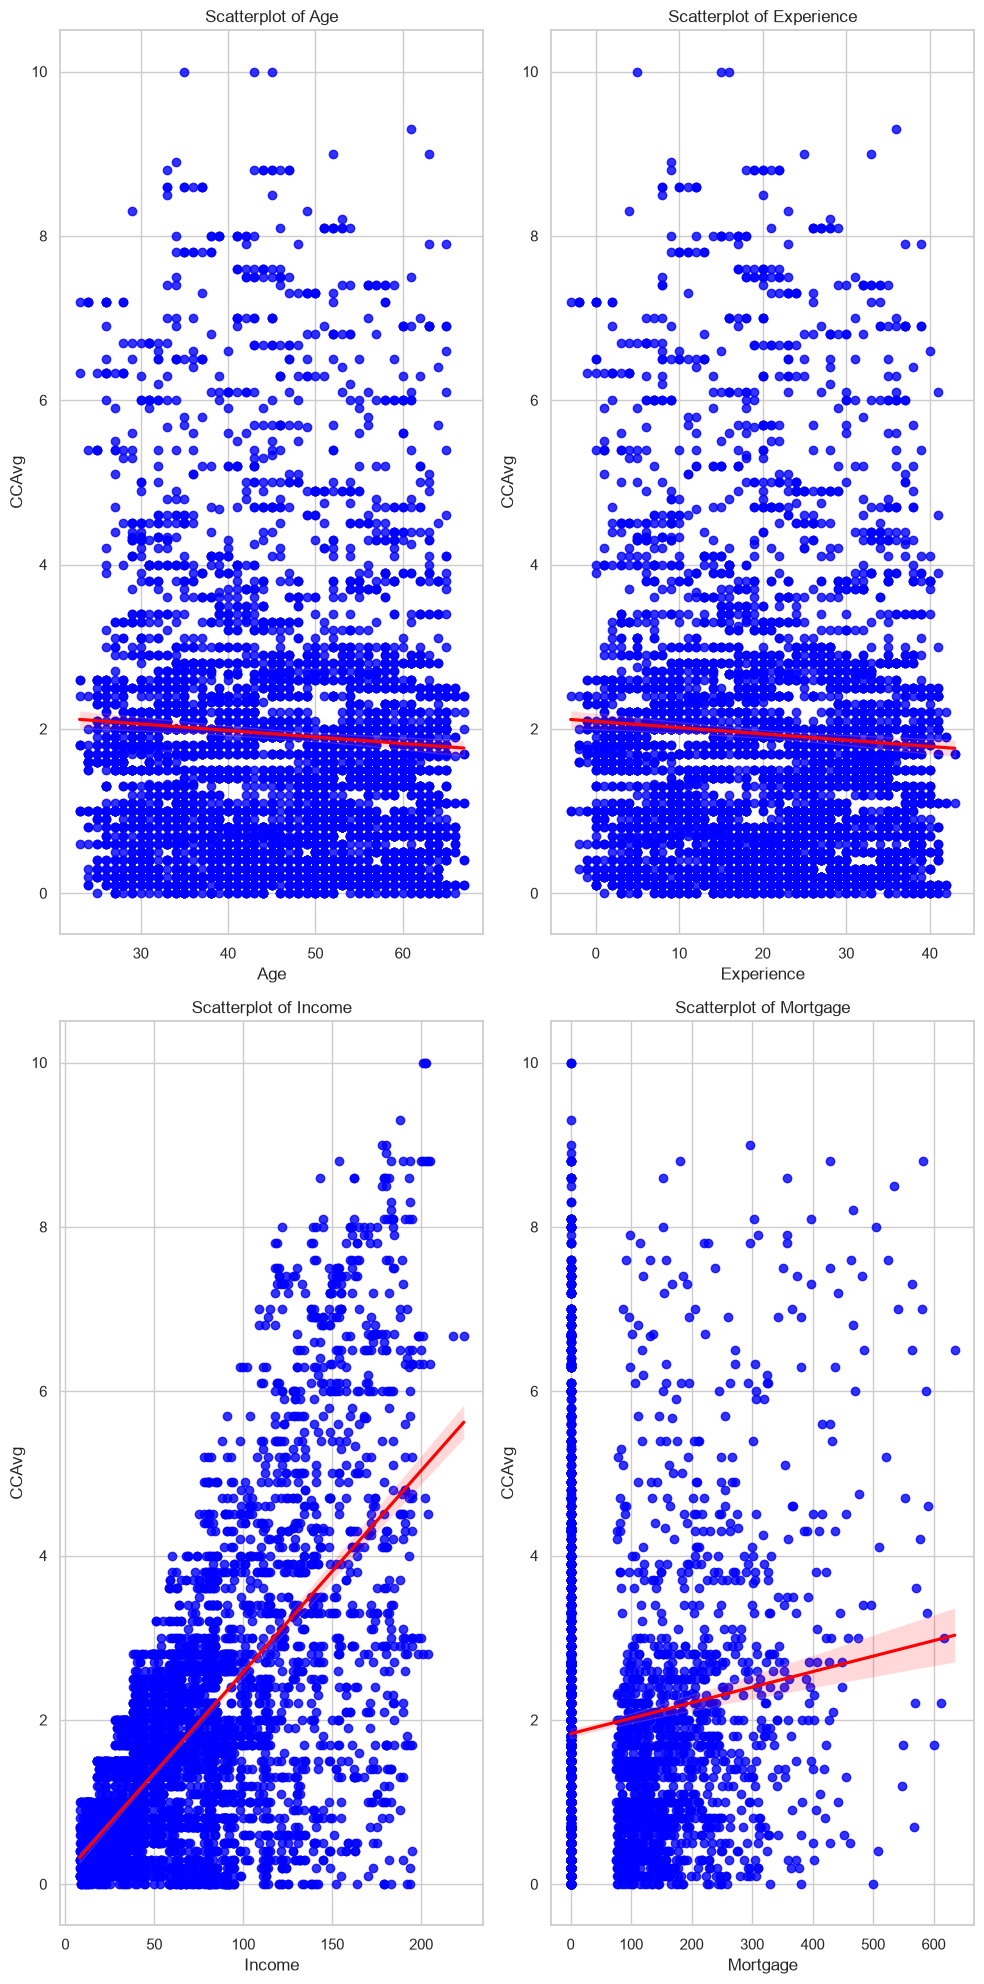

In [16]:
continous_columns = ['Age','Experience','Income','Mortgage']
fig,axes = plt.subplots(nrows = 2, ncols = 2,figsize = (10,20))
axes_flatten = axes.flatten()
for i, col_name in enumerate(continous_columns):
    sns.regplot(x = col_name, y = 'CCAvg',data = df,ax = axes_flatten[i],scatter_kws = {'color':'blue'},line_kws = {'color':'red'})
    axes_flatten[i].set_title(f'Scatterplot of {col_name}')
    axes_flatten[i].set_xlabel(col_name)
plt.tight_layout()
plt.show()

From these plots we notice:
- The regression line is flat for Age, Experience which shows by themselves there is no correlation with CCAvg. This is also indicated by the scatterplots not forming a pattern.
- For income there is a clear trend that indicates as income increases the CCAvg increases. This is something I would expect since having a higher income would increase purchasing power so will be able to spend more on the credit card and may aslo have a higher limit.
- For Mortgage it is showing a positive correlation. Not as strong as Income. Although this correlation line is dependent on the fact that majority of customers have no mortgage.

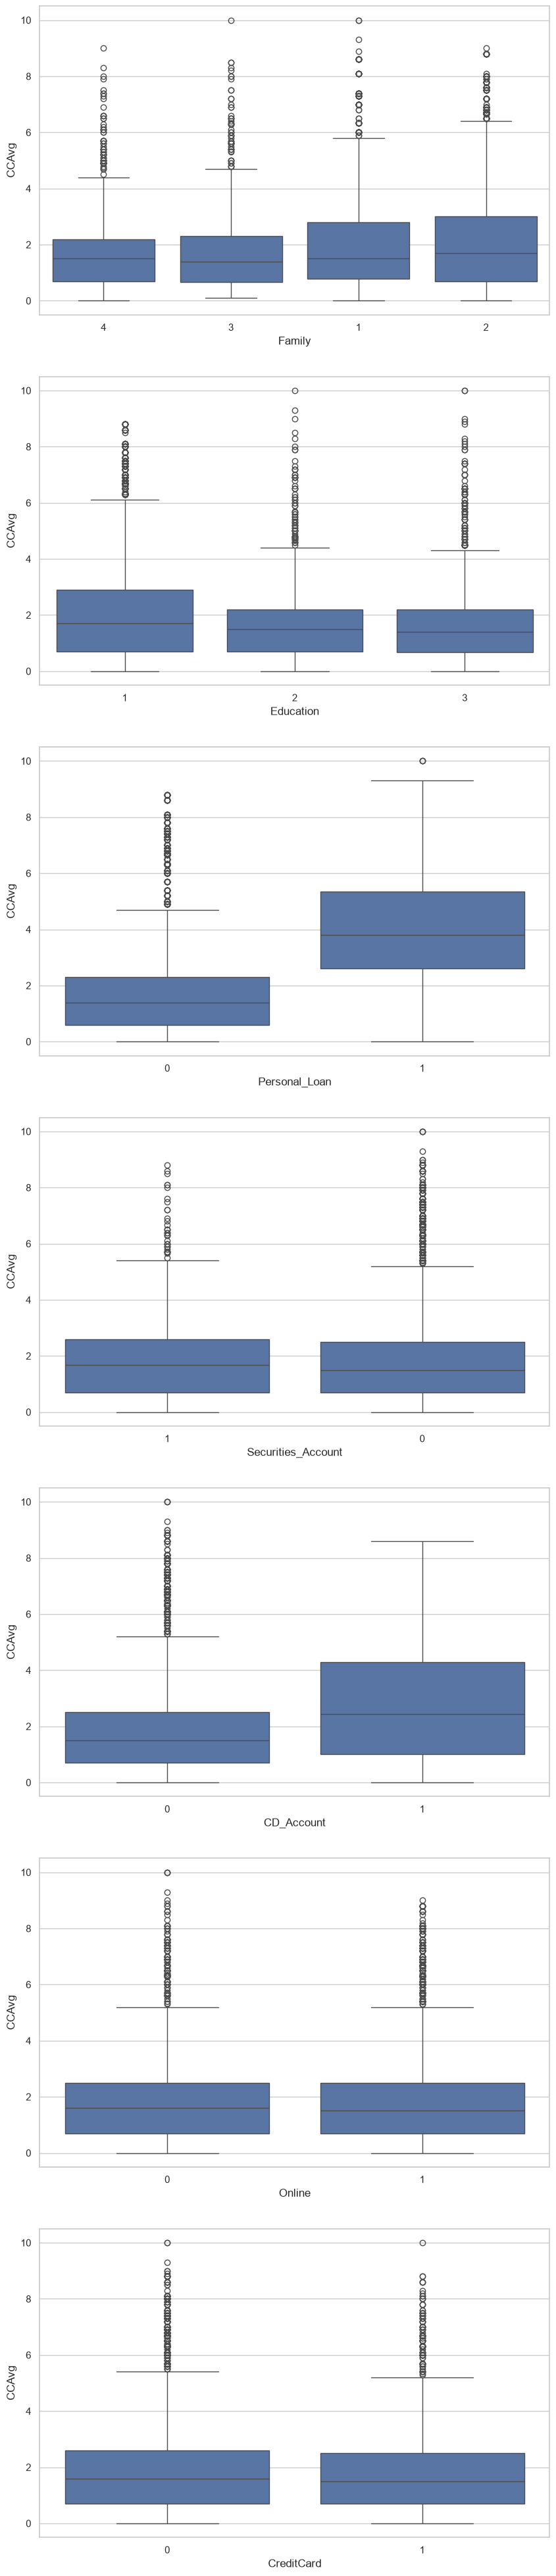

In [17]:
discrete_columns = ['Family','Education','Personal_Loan','Securities_Account','CD_Account','Online','CreditCard']
fig,axes = plt.subplots(nrows = 7, ncols = 1, figsize = (10,50))
axes_flatten = axes.flatten()
for i,col_name in enumerate(discrete_columns):
     sns.boxplot(x = df[col_name].astype(str),y = df['CCAvg'],ax = axes_flatten[i])

From these boxplots we can say:
- Family,Education, Securities Account, Online do not appear to have a strong relationship with CCAvg.
- PersonalLoan, people who accept a loan tend to have a higher CCAvg. This may be an interesting observation to note when moving onto predicting if a customer will accept a loan.
- CD Account there is a fairly strong relationship in that customers who have a CD Account are likely to spend more. This is something I would expect since if customers are able to put away money into a fixed deposit and not touch the money, they may be more financially stable and this can lead to them being able to spend more on credit card.

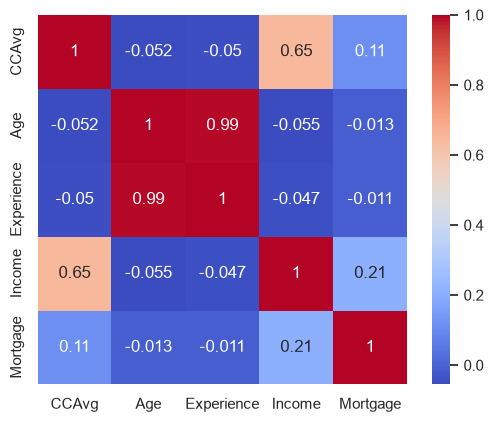

In [18]:
continous_columns = ['CCAvg','Age','Experience','Income','Mortgage',]
correlation_matrix = df[continous_columns].corr()
sns.heatmap(correlation_matrix,
            annot = True,
            cmap = 'coolwarm',
            square = True)
plt.show()

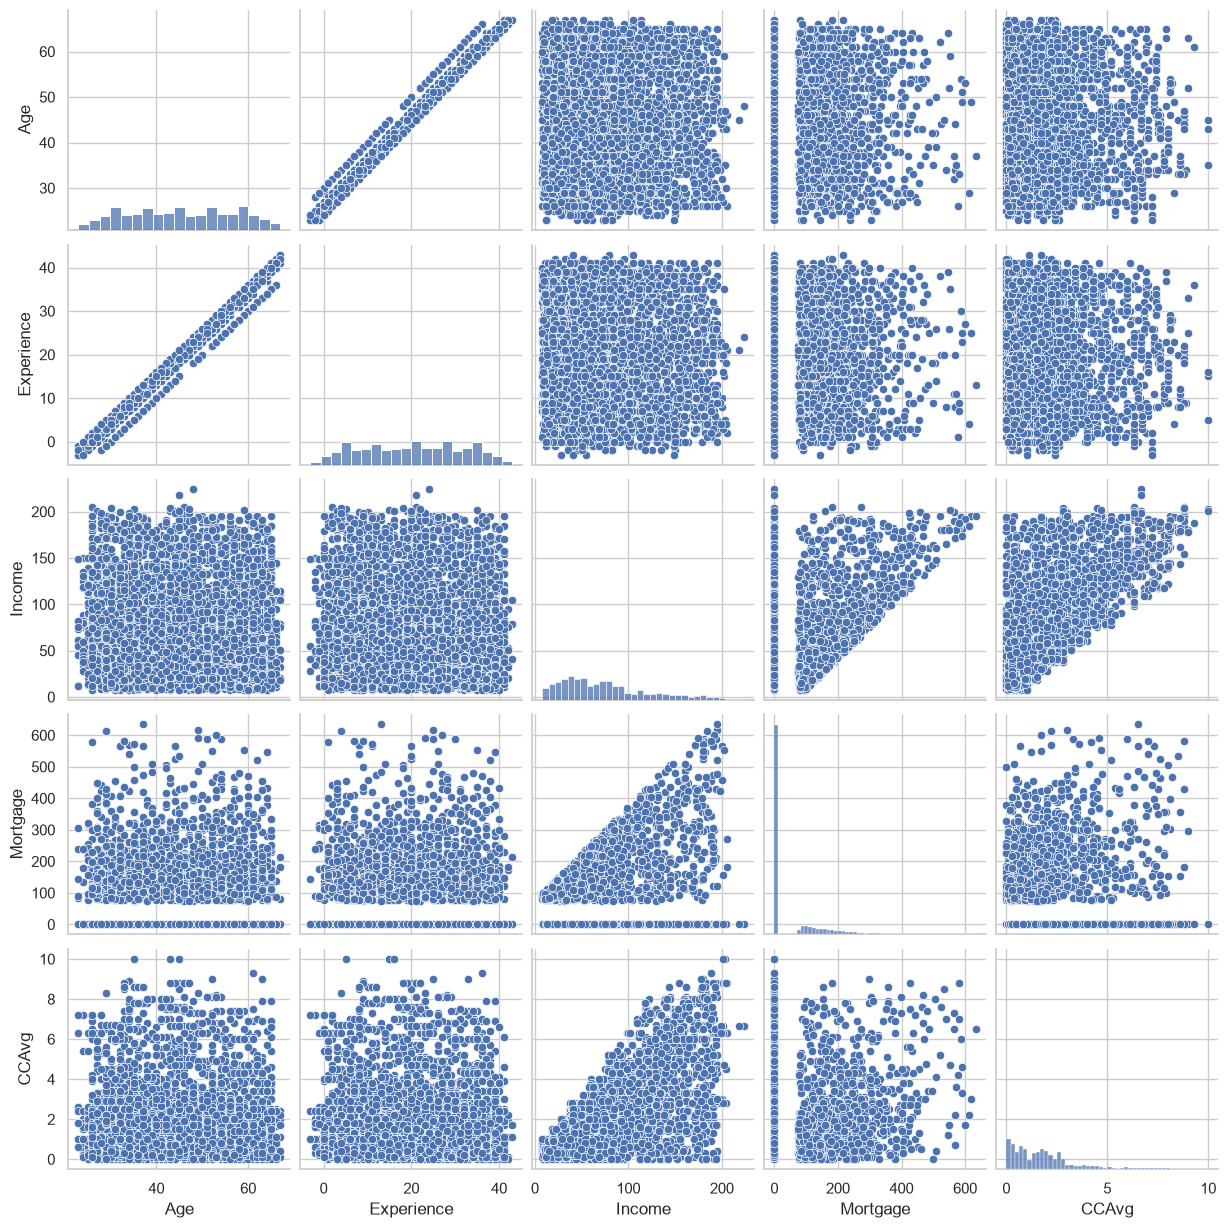

In [19]:
continous_columns = ['Age','Experience','Income','Mortgage','CCAvg']
sns.pairplot(df[continous_columns])
plt.show()

From the heatmap, main observations:
- Income has a strong positive linear relationship with CCAvg.
- Age and Experience had a very strong linear correlation so when it comes to modelling will need to consider that so we don't end up with multicolinearity.
- From the pairplot, we see for majority of the data, it is scattered around and there are no obvious trends or patterns we can see from this at this. This is both for linear trends and other types of trends.

## Data Pre-Processing

In [20]:
def adj_r2_score(predictors, r2):
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

def model_evaluation(mae,mape,rmse,mse,r2,adjusted_r2):
    evaluation_metrics = {'MSE':mse,'RMSE':rmse,'MAE':mae,'MAPE':mape,'R^2':r2,'Adjusted R^2':adjusted_r2}
    evaluation_metrics = pd.DataFrame(evaluation_metrics,index = [0])
    return evaluation_metrics



### Train-test Split

In [21]:
feature_columns = ['Age','Experience','Income','Family','Education','Mortgage','Securities_Account','CD_Account','Online','CreditCard']
X = df[feature_columns]
y_reg = df['CCAvg']
y_clf = df['Personal_Loan']
X_train,X_test,y_reg_train,y_reg_test,y_clf_train,y_clf_test = train_test_split(X,y_reg,y_clf,test_size = 0.2,random_state = 1,stratify=y_clf)

In [22]:
continous_features = ['Age','Experience','Income','Mortgage']
X_train[continous_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4000.0,45.33525,11.454024,23.0,35.0,45.0,55.0,67.0
Experience,4000.0,20.10900,11.460212,-3.0,10.0,20.0,30.0,43.0
Income,4000.0,74.17650,45.942530,8.0,39.0,64.0,99.0,224.0
Mortgage,4000.0,57.53275,102.911144,0.0,0.0,0.0,102.0,635.0


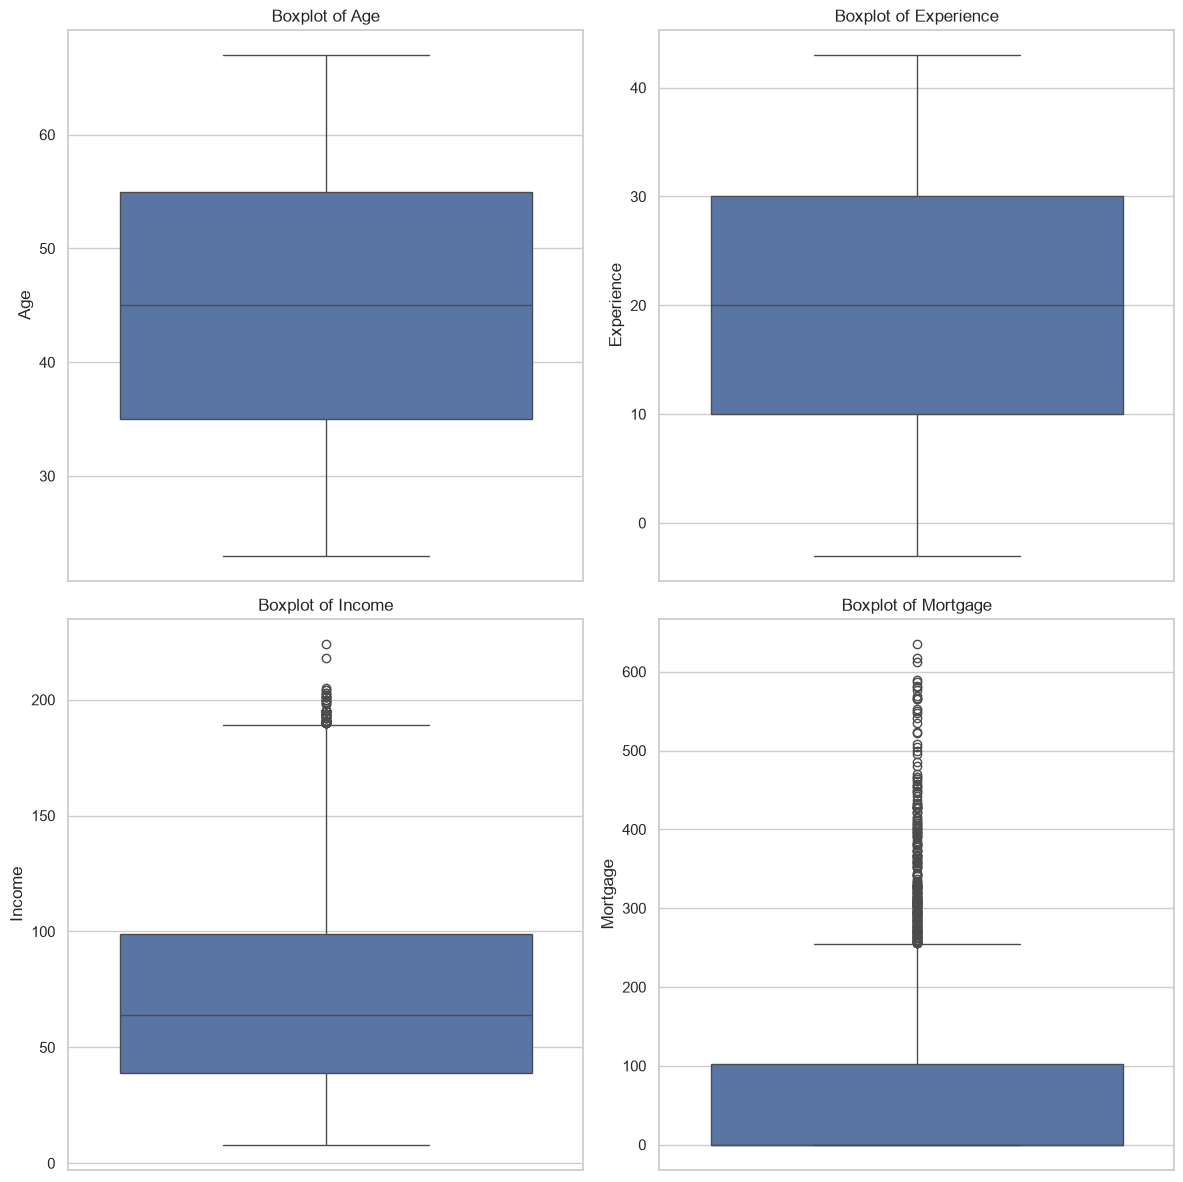

In [23]:
fig,axes = plt.subplots(2,2,figsize = (12,12))
axes_flatten = axes.flatten()
for i, col_name in enumerate(continous_features):
    sns.boxplot(y = X_train[col_name],ax = axes_flatten[i])
    axes_flatten[i].set_title(f'Boxplot of {col_name}')
plt.tight_layout()
plt.show()

In [24]:
print("Target variable summary statistics:")
display(y_reg_train.describe())

Target variable summary statistics:


count    4000.000000
mean        1.954850
std         1.760854
min         0.000000
25%         0.700000
50%         1.500000
75%         2.600000
max        10.000000
Name: CCAvg, dtype: float64

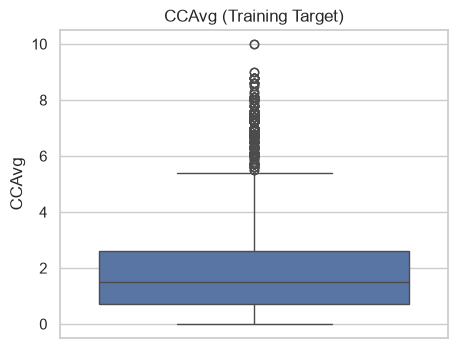

In [25]:
plt.figure(figsize=(5, 4))
sns.boxplot(y=y_reg_train)
plt.title("CCAvg (Training Target)")
plt.show()

In [26]:
log_features = ['Income','Mortgage']
numeric_features = ['Age']
ordinal_features = ['Education','Family']
binary_features = ['Securities_Account','CD_Account','Online','CreditCard']
absolute_features = ['Experience']
numeric_pipeline = Pipeline([
    ('scaler',StandardScaler())
])
log_pipeline = Pipeline([
    ('log',FunctionTransformer(np.log1p,validate = False)),
    ('scaler',StandardScaler())
])
experience_pipeline = Pipeline([
    ('absolute',FunctionTransformer(np.abs,validate = False)),
    ('scaler',StandardScaler())
])

preprocessor = ColumnTransformer([
    ('age',numeric_pipeline,numeric_features),
    ('exp',experience_pipeline,absolute_features),
    ('log',log_pipeline,log_features),
    ('ord','passthrough',ordinal_features),
    ('bin','passthrough',binary_features)
])
preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)
lin_reg_original = LinearRegression()
lin_reg_original.fit(X_train_processed,y_reg_train)
pred_reg = lin_reg_original.predict(X_test_processed)


In [27]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('age', ...), ('exp', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [28]:
mae = mean_absolute_error(y_reg_test,pred_reg)
mape = mean_absolute_percentage_error(y_reg_test,pred_reg)
rmse = root_mean_squared_error(y_reg_test,pred_reg)
mse = rmse ** 2
r2 = r2_score(y_reg_test,pred_reg)
adjusted_r2 = adj_r2_score(X_train_processed,r2)
regression_model_evaluation = model_evaluation(mae,mape,rmse,mse,r2,adjusted_r2)
regression_model_evaluation

,MSE,RMSE,MAE,MAPE,R^2,Adjusted R^2
0,1.789858,1.337856,0.980829,1.777133e+14,0.374933,0.373366


In [29]:
feature_names = X_train.columns.tolist()
coef_table = pd.DataFrame({'feature': feature_names, 'coefficient': lin_reg_original.coef_}).sort_values(
    'coefficient', key=abs, ascending=False).reset_index(drop=True)
coef_table


,feature,coefficient
0,Income,1.002253
1,CD_Account,0.568947
2,Experience,-0.432674
3,Age,0.399305
4,Education,-0.097624
5,CreditCard,-0.089537
6,Online,-0.088140
7,Mortgage,-0.054308
8,Securities_Account,-0.031901
9,Family,-0.010080


In [30]:
X_train.drop(columns=['Age','Education','CreditCard','Online','Mortgage','Securities_Account','Family'],inplace = True)

In [31]:
log_features = ['Income']
binary_features = ['CD_Account']
absolute_features = ['Experience']

preprocessor = ColumnTransformer([
    ('exp',experience_pipeline,absolute_features),
    ('log',log_pipeline,log_features),
    ('bin','passthrough',binary_features)
])
preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)
lin_reg_important_features = LinearRegression()
lin_reg_important_features.fit(X_train_processed,y_reg_train)
pred_reg = lin_reg_important_features.predict(X_test_processed)


In [32]:
mae = mean_absolute_error(y_reg_test,pred_reg)
mape = mean_absolute_percentage_error(y_reg_test,pred_reg)
rmse = root_mean_squared_error(y_reg_test,pred_reg)
mse = rmse ** 2
r2 = r2_score(y_reg_test,pred_reg)
adjusted_r2 = adj_r2_score(X_train_processed,r2)
regression_model_evaluation = model_evaluation(mae,mape,rmse,mse,r2,adjusted_r2)
regression_model_evaluation

,MSE,RMSE,MAE,MAPE,R^2,Adjusted R^2
0,1.809691,1.345247,0.98661,1.797973e+14,0.368006,0.367532


In [33]:
feature_names = X_train.columns.tolist()
coef_table = pd.DataFrame({'feature': feature_names, 'coefficient': lin_reg_important_features.coef_}).sort_values(
    'coefficient', key=abs, ascending=False).reset_index(drop=True)
coef_table


,feature,coefficient
0,Income,1.024672
1,CD_Account,0.447109
2,Experience,-0.032701


Chosen model will be the original.

In [34]:
feature_columns = ['Age','Experience','Income','Family','Education','Mortgage','Securities_Account','CD_Account','Online','CreditCard']
X = df[feature_columns]
y_reg = df['CCAvg']
y_clf = df['Personal_Loan']
X_train,X_test,y_reg_train,y_reg_test,y_clf_train,y_clf_test = train_test_split(X,y_reg,y_clf,test_size = 0.2,random_state = 1,stratify=y_clf)
log_features = ['Income','Mortgage']
numeric_features = ['Age']
ordinal_features = ['Education','Family']
binary_features = ['Securities_Account','CD_Account','Online','CreditCard']
absolute_features = ['Experience']
numeric_pipeline = Pipeline([
    ('scaler',StandardScaler())
])
log_pipeline = Pipeline([
    ('log',FunctionTransformer(np.log1p,validate = False)),
    ('scaler',StandardScaler())
])
experience_pipeline = Pipeline([
    ('absolute',FunctionTransformer(np.abs,validate = False)),
    ('scaler',StandardScaler())
])

preprocessor = ColumnTransformer([
    ('age',numeric_pipeline,numeric_features),
    ('exp',experience_pipeline,absolute_features),
    ('log',log_pipeline,log_features),
    ('ord','passthrough',ordinal_features),
    ('bin','passthrough',binary_features)
])
preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)
lin_reg_original = LinearRegression()
lin_reg_original.fit(X_train_processed,y_reg_train)
ccavg_train_pred = lin_reg_original.predict(X_train_processed)
ccavg_test_pred = lin_reg_original.predict(X_test_processed)


In [35]:
feature_names = X_train.columns

X_train_clf = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_clf = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)
X_train_clf["Predicted_CCAvg"] = ccavg_train_pred
X_test_clf["Predicted_CCAvg"] = ccavg_test_pred

In [36]:
X_train_clf

,Age,Experience,Income,Family,Education,Mortgage,Securities_Account,CD_Account,Online,CreditCard,Predicted_CCAvg
4975,-0.640488,-0.801989,-1.051328,-0.667086,2.0,4.0,0.0,0.0,1.0,0.0,0.858970
4997,1.542424,1.654197,-1.320233,-0.667086,3.0,2.0,0.0,0.0,0.0,0.0,0.497510
1259,0.581943,0.601546,-0.782422,-0.667086,2.0,4.0,0.0,0.0,1.0,0.0,1.009331
1838,-1.251704,-1.152872,0.724407,-0.667086,1.0,1.0,0.0,0.0,1.0,0.0,2.807007
3106,-0.815121,-0.889709,-1.508774,-0.667086,2.0,3.0,0.0,0.0,0.0,0.0,0.511163
...,...,...,...,...,...,...,...,...,...,...,...
4073,0.494626,0.601546,-1.649346,-0.667086,1.0,1.0,0.0,0.0,0.0,0.0,0.454274
4834,0.319993,0.250663,0.219269,1.598848,1.0,1.0,0.0,0.0,0.0,0.0,2.386344
3207,0.931208,1.040151,0.484708,-0.667086,1.0,1.0,0.0,0.0,1.0,1.0,2.400016
1437,-1.513653,-1.503756,1.041674,1.433016,1.0,1.0,0.0,0.0,0.0,0.0,3.239179


## Classification Model

In [37]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=1),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Random Forest': RandomForestClassifier(random_state=1),
}

results = []
for name, clf in classifiers.items():
    clf.fit(X_train_clf, y_clf_train)
    preds = clf.predict(X_test_clf)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_clf_test, preds),
        'Precision': precision_score(y_clf_test, preds, zero_division=0),
        'Recall': recall_score(y_clf_test, preds, zero_division=0),
        'F1': f1_score(y_clf_test, preds, zero_division=0),
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.976,0.909091,0.833333,0.869565
1,Decision Tree,0.967,0.824742,0.833333,0.829016
2,SVM,0.962,0.902778,0.677083,0.773810
3,KNN,0.960,0.924242,0.635417,0.753086
4,Logistic Regression,0.947,0.811594,0.583333,0.678788
5,Naive Bayes,0.932,0.627273,0.718750,0.669903
